

The cleanest path is:

$$
\boxed{
\text{Forward model}
\rightarrow
\text{Loss}
\rightarrow
\text{manual perturbation}
\rightarrow
\text{finite-difference gradient}
\rightarrow
\text{gradient descent}
\rightarrow
\text{analytic gradient / backprop}
}
$$

Start from a phase mask:

$$
U_0=Ae^{i\phi}.
$$

Propagation:

$$
U_z=\mathcal P(U_0).
$$

Intensity:

$$
I=|U_z|^2.
$$

Target error:

$$
L(\phi)
=
\frac{1}{N}
\sum_{x,y}
\left(I-I_{\rm target}\right)^2.
$$

Now pick just **one phase pixel** $\phi_{m,n}$.

Instead of automatic differentiation, calculate its derivative numerically:

$$
\frac{\partial L}{\partial\phi_{m,n}}
\approx
\frac{
L(\phi_{m,n}+\epsilon)
-
L(\phi_{m,n}-\epsilon)
}{
2\epsilon
}.
$$

This means:

1. run ASM normally and calculate $L$;
2. slightly increase one phase pixel;
3. propagate again and calculate $L_+$;
4. slightly decrease it;
5. propagate again and calculate $L_-$;
6. estimate the slope.

Then update:

$$
\phi_{m,n}
\leftarrow
\phi_{m,n}
-
\eta
\frac{\partial L}{\partial\phi_{m,n}}.
$$

That is already **inverse design from scratch**. No PyTorch, no autograd, no black box.

The first experiment I suggest is deliberately tiny: perhaps a $32\times32$ phase mask and a very simple target intensity—one bright spot displaced from the center. Then we can literally observe:

$$
\text{random phase}
\rightarrow
\text{calculate gradient}
\rightarrow
\text{change phase}
\rightarrow
\text{spot gradually forms}.
$$

After you understand that loop physically, we derive why the gradient can be computed much more efficiently than perturbing every pixel separately. That will naturally lead us to the **adjoint/backpropagation method**, and only after that does PyTorch become useful rather than magical.

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from wave_optics import ifft2c, visualize, visualize_grid, make_grid, k_freq_grid, asm

Nx = 32
Ny = 32

dx = 2e-6
dy = dx


wavelength = 532e-9

X, Y, x, y = make_grid(Nx, Ny, dx, dy)

A = 1  # plane wave
z = 0.01

epsilon = 0.001
learning_rate = 0.1


def model(epsilon, learning_rate, n):
    # forward propagation
    def get_Iz(A, phi, z):
        U0 = A * np.exp(1j * phi)
        Uz, _, _ = asm(U0, z, wavelength, dx, dy)
        Iz = np.abs(Uz) ** 2
        Iz = Iz / Iz.sum()
        return Iz

    # caculate current loss
    def loss(phi):
        Iz = get_Iz(A, phi, z)
        return np.sum(np.abs(I_target - Iz) ** 2)
        # return np.sum(np.abs(I_target - Iz) ** 2) / (Nx * Ny) # 分成Nx * Ny 会让损失很小，不好比较

    def build_I_target(Nx, Ny):

        I_target = np.zeros((Nx, Ny))
        # choose an off-axis pixel
        m0 = Nx // 2
        n0 = Ny // 2 + 1
        I_target[m0, n0] = 1.0
        return I_target

    I_target = build_I_target(Nx, Ny)

    phi = np.zeros((Nx, Ny)).astype(float)
    loss_history = [loss(phi)]

    def training(count, phi):
        grad = np.zeros((Nx, Ny))

        for c in range(count):
            grad = np.zeros_like(phi)
            for m in range(Nx):
                for n in range(Ny):
                    # + epsilon
                    phi_plus = phi.copy()
                    phi_plus[m, n] = phi_plus[m, n] + epsilon

                    # - epsilon
                    phi_minus = phi.copy()
                    phi_minus[m, n] = phi_minus[m, n] - epsilon

                    # derivative for this one pixel
                    grad[m, n] = (loss(phi_plus) - loss(phi_minus)) / (2 * epsilon)
                    # plt.imshow(grad, cmap="gray")
                    # plt.colorbar(label="dL/dphi")
                    # plt.show()
            # Update the entire phase matrix
            phi = phi - learning_rate * grad
            loss_history.append(loss(phi))
            print(c, loss_history[-1], np.linalg.norm(grad))

        return phi

    phi = training(n, phi)
    I_z = get_Iz(A, phi, z)
    return phi, I_target, I_z, loss_history


# phi, I_target, I_z = model(epsilon, learning_rate, 1)

# visualize_grid(
#     lambda: visualize(np.sqrt(I_target), x, y),
#     lambda: visualize(np.sqrt(I_z), x, y),
#     col=2,
# )

## Different Learning Rate
learning_rates = [
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1
]

0 0.9990226634374605 0.002782059205682442
1 0.9990218890665866 0.0027826132428332355
2 0.9990211143872554 0.0027831673905563377
[np.float64(0.9990234375), np.float64(0.9990226634374605), np.float64(0.9990218890665866), np.float64(0.9990211143872554)]
0 0.9990156899385303 0.002782059205682442
1 0.9990079114884085 0.0027875995543485497
2 0.9990001020262055 0.002793150986365617
[np.float64(0.9990234375), np.float64(0.9990156899385303), np.float64(0.9990079114884085), np.float64(0.9990001020262055)]
0 0.9989452683402927 0.002782059205682442
1 0.9988639548456292 0.002837460310116349
2 0.9987793703017577 0.0028939688615454238
[np.float64(0.9990234375), np.float64(0.9989452683402927), np.float64(0.9988639548456292), np.float64(0.9987793703017577)]
0 0.9981724603988681 0.002782059205682442
1 0.9969491659686052 0.0033356858879803305
2 0.9951914781225583 0.003998896725964707
[np.float64(0.9990234375), np.float64(0.9981724603988681), np.float64(0.9969491659686052), np.float64(0.9951914781225583)]

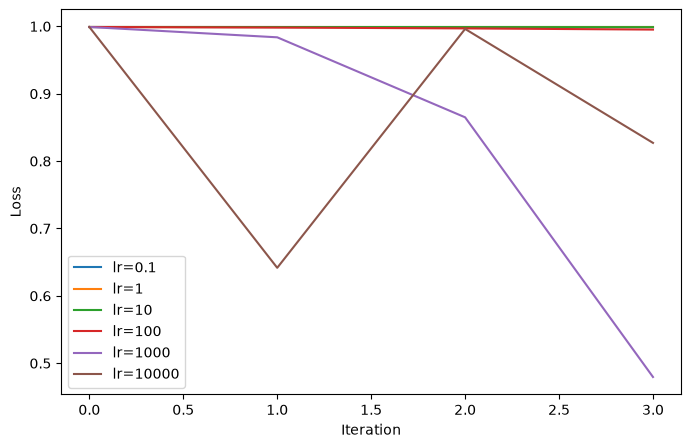

In [ ]:
# learning_rates = [1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3]
learning_rates = [0.1, 1, 10, 100, 1000, 10000]

loss_historys = []

plt.figure(figsize=(8, 5))


for lr in learning_rates:
    phi, I_target, I_z, loss_history = model(epsilon, lr, 3)
    # loss_historys.append(loss_history)
    # print(loss_history)
    plt.plot(loss_history, label=f"lr={lr}")


plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

# phi, I_target, I_z, loss_history = model(epsilon, learning_rates[0], 1)

## Physical constraint
1. phi [0, 2pi)：`phi = np.mod(phi - learning_rate * grad, 2 * np.pi)`
2. 真实的光学系统有孔径: 假设圆形孔径，
```
if X[m, n]\*\*2 + Y[m, n]**2 <= R**2:  &#x20;
&#x20; phi[m, n] = np.mod(phi[m,n] - learning\_rate \* grad[m,n], 2 \* np.pi)
```
3. 采样频率 phase quantization

delta_phi = 2 * np.pi / 256

phi_quantized = (
    np.round(phi / delta_phi)
    * delta_phi
)

phi_quantized = np.mod(phi_quantized, 2 * np.pi)

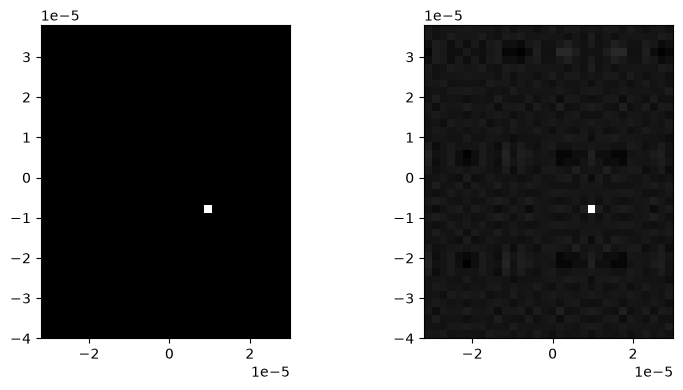

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from wave_optics import ifft2c, visualize, visualize_grid, make_grid, k_freq_grid, asm

# Nx = number of x samples
# Ny = number of y samples

# array.shape == (Ny, Nx)

# ix = x index
# iy = y index

# array[iy, ix]

Nx = 32
Ny = 40

dx = 2e-6
dy = dx


wavelength = 532e-9

X, Y, x, y = make_grid(Nx, Ny, dx, dy)

z = 0.01

epsilon = 0.001
learning_rate = 0.1
R = Nx * dx
# 方式1：布尔转整数，最推荐，简洁
A = ((X**2 + Y**2) <= R**2).astype(np.float64)

# 方式2：np.where，完全对应你 ? 1:0 三元表达式
# A = np.where((X**2 + Y**2) <= R**2, 1, 0)

delta_phi = 2 * np.pi / 256000


def model(epsilon, learning_rate, n):
    # forward propagation
    def get_Iz(A, phi, z):
        U0 = A * np.exp(1j * phi)
        Uz, _, _ = asm(U0, z, wavelength, dx, dy)
        Iz = np.abs(Uz) ** 2
        Iz = Iz / Iz.sum()
        return Iz

    # caculate current loss
    def loss(phi):
        Iz = get_Iz(A, phi, z)
        return np.sum(np.abs(I_target - Iz) ** 2)
        # return np.sum(np.abs(I_target - Iz) ** 2) / (Nx * Ny) # 分成Nx * Ny 会让损失很小，不好比较

    def build_I_target(Nx, Ny):

        I_target = np.zeros((Ny, Nx))
        # choose an off-axis pixel
        m0 = Nx // 2
        n0 = Ny // 2 + 1
        I_target[m0, n0] = 1.0
        return I_target

    I_target = build_I_target(Nx, Ny)

    phi = np.zeros((Ny, Nx)).astype(float)
    loss_history = [loss(phi)]

    def training(count, phi):
        grad = np.zeros((Ny, Nx))

        for c in range(count):
            grad = np.zeros_like(phi)
            for m in range(Ny):
                for n in range(Nx):

                    if A[m, n] == 0:
                        continue
                    # + epsilon
                    phi_plus = phi.copy()
                    phi_plus[m, n] = phi_plus[m, n] + epsilon

                    # - epsilon
                    phi_minus = phi.copy()
                    phi_minus[m, n] = phi_minus[m, n] - epsilon

                    # derivative for this one pixel
                    grad[m, n] = (loss(phi_plus) - loss(phi_minus)) / (2 * epsilon)

            # 2. Only now update the whole phase field
            phi = np.mod(phi - learning_rate * grad * A, 2 * np.pi)

            loss_history.append(loss(phi))

        return phi

    phi = training(n, phi)
    # after optimization, simulate the actual SLM
    # simulate the real SLM AFTER optimization
    phi_slm = np.mod(np.round(phi / delta_phi) * delta_phi, 2 * np.pi)
    I_z = get_Iz(A, phi, z)
    return phi, I_target, I_z, loss_history, phi_slm


phi, I_target, I_z, _, _ = model(epsilon, learning_rate, 1)

visualize_grid(
    lambda: visualize(np.sqrt(I_target), x, y),
    lambda: visualize(np.sqrt(I_z), x, y),
    col=2,
)